# TrOCR / placas españolas (UC3M-LP) en Docker

Adaptado de `TrOCR_IAM.ipynb` (basado en el [cuaderno de Niels Rogge](https://github.com/NielsRogge/Transformers-Tutorials/blob/master/TrOCR/Fine_tune_TrOCR_on_IAM_Handwriting_Database_using_Seq2SeqTrainer.ipynb)).
En lugar de líneas manuscritas de IAM, ajusta TrOCR con los recortes de placas del dataset UC3M-LP
(`data/ocr_vehicles/UC3M-LP`). El modelo resultante (`outputs/trocr_placas/final`) es el OCR que usa
`Pipeline_Placas_OCR.ipynb`.

Selecciona el kernel **Python (TrOCR)**.

Diferencias con el cuaderno de IAM:

* Los recortes de placa se generan a partir de los JSON de UC3M-LP y se guardan con margen extra alrededor de la placa.
* **Aumento de datos** en entrenamiento: en cada época cada placa se recorta con un margen aleatorio (como las cajas
  variables del detector), se rota ligeramente, se cambian brillo, contraste y color, se desenfoca, se comprime en JPEG
  y se reduce a baja resolución. Validación y test usan siempre el mismo recorte que el pipeline.
* UC3M-LP anonimiza dos caracteres de cada placa con un bloque gris. El texto objetivo los marca con `*`
  (`074*C*V`), para que cada carácter visible conserve su posición.
* Las etiquetas no empiezan con `<s>`: el decodificador ya lo recibe como token inicial. Con `<s>` en las etiquetas el
  modelo aprende a predecirlo y, ante placas desconocidas, lo repite hasta el límite y devuelve un texto vacío.
* La validación se separa de `train` agrupando por placa, porque la misma placa aparece en varias fotos. `test` se
  reserva para la evaluación final, que se hace también con las placas reducidas a baja resolución.
* Batch de 16, hasta 40 épocas con *early stopping* sobre el CER de validación, y se conserva el mejor checkpoint.
* La generación no usa `no_repeat_ngram_size` ni `length_penalty`: en una placa los caracteres pueden repetirse y la
  longitud es fija.

## Preparar los datos

Cada imagen de UC3M-LP tiene un JSON con sus placas: `lp_id` (por ejemplo `AN-074*C*V`; el prefijo antes del guion es
la categoría de la placa y `*` marca los caracteres anonimizados), el polígono de la placa (`poly_coord`) y las cajas de
los caracteres visibles.

Para cada placa se toma el rectángulo que contiene el polígono y se guarda un recorte con `CROP_CONTEXT` de margen, más
amplio que el del pipeline, para que el aumento de datos pueda elegir márgenes distintos. El recorte se reduce a
`CROP_MAX_SIDE` píxeles como máximo (TrOCR lo redimensiona a 384×384 de todos modos). Para cada partición se escribe un
CSV con el texto y la posición de la placa dentro del recorte. Los recortes se generan una sola vez: si ya existen, se
reutilizan.

El campo `imagePath` de los JSON está desplazado una posición (`00000.json` indica `00001.jpg`), así que la imagen se
toma del nombre del propio JSON: `00000.jpg`.

In [1]:
import os
import json
import math
import random
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
UC3M_DIR = Path(os.environ.get("UC3M_DATA_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP"))
DATA_DIR = Path(os.environ.get("PLATES_OCR_DATA_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP_ocr"))
OUTPUT_DIR = Path(os.environ.get("TROCR_OUTPUT_DIR", project_dir / "outputs")) / "trocr_placas"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROP_PADDING = (0.08, 0.15)  # (horizontal, vertical), igual que en Pipeline_Placas_OCR.ipynb
CROP_CONTEXT = (0.25, 0.45)  # margen guardado alrededor de la placa, para el aumento de datos
CROP_MAX_SIDE = 768
VALIDATION_FRACTION = 0.1
SEED = 42


def ampliar_caja(caja, padding, ancho, alto):
    x0, y0, x1, y1 = caja
    pad_x = (x1 - x0) * padding[0]
    pad_y = (y1 - y0) * padding[1]
    return (
        max(0, int(x0 - pad_x)),
        max(0, int(y0 - pad_y)),
        min(ancho, math.ceil(x1 + pad_x)),
        min(alto, math.ceil(y1 + pad_y)),
    )


def preparar_recortes(split):
    destino = DATA_DIR / "image" / split
    destino.mkdir(parents=True, exist_ok=True)
    filas = []
    ids = (UC3M_DIR / f"{split}.txt").read_text(encoding="utf-8").split()
    for image_id in tqdm(ids, desc=split):
        anotacion = json.loads((UC3M_DIR / split / f"{image_id}.json").read_text(encoding="utf-8"))
        imagen = None
        for i, placa in enumerate(anotacion["lps"]):
            xs = [x for x, _ in placa["poly_coord"]]
            ys = [y for _, y in placa["poly_coord"]]
            caja = (min(xs), min(ys), max(xs), max(ys))
            contexto = ampliar_caja(caja, CROP_CONTEXT, anotacion["imageWidth"], anotacion["imageHeight"])
            escala = min(1.0, CROP_MAX_SIDE / max(contexto[2] - contexto[0], contexto[3] - contexto[1]))
            nombre = f"{split}/{image_id}_{i}.jpg"
            if not (DATA_DIR / "image" / nombre).is_file():
                if imagen is None:
                    with Image.open(UC3M_DIR / split / f"{image_id}.jpg") as original:
                        imagen = original.convert("RGB")
                    if imagen.size != (anotacion["imageWidth"], anotacion["imageHeight"]):
                        raise ValueError(f"{image_id}: la imagen mide {imagen.size}, el JSON indica otro tamaño")
                recorte = imagen.crop(contexto)
                if escala < 1:
                    recorte = recorte.resize((round(recorte.width * escala), round(recorte.height * escala)),
                                             Image.LANCZOS)
                recorte.save(DATA_DIR / "image" / nombre, quality=95)
            categoria, texto = placa["lp_id"].split("-", 1)
            filas.append({
                "file_name": nombre, "text": texto, "categoria": categoria,
                # posición de la placa dentro del recorte guardado
                "x0": (caja[0] - contexto[0]) * escala, "y0": (caja[1] - contexto[1]) * escala,
                "x1": (caja[2] - contexto[0]) * escala, "y1": (caja[3] - contexto[1]) * escala,
            })
    return pd.DataFrame(filas)


if not all((DATA_DIR / f"{split}.csv").is_file() for split in ("train", "validation", "test")):
    train_all = preparar_recortes("train")
    test_all = preparar_recortes("test")
    # La misma placa aparece en varias fotos: se separa la validación por placa para no evaluar con placas vistas.
    placas = sorted(train_all["text"].unique())
    random.Random(SEED).shuffle(placas)
    placas_validacion = set(placas[:round(len(placas) * VALIDATION_FRACTION)])
    es_validacion = train_all["text"].isin(placas_validacion)
    train_all[~es_validacion].to_csv(DATA_DIR / "train.csv", index=False)
    train_all[es_validacion].to_csv(DATA_DIR / "validation.csv", index=False)
    test_all.to_csv(DATA_DIR / "test.csv", index=False)
    print("Recortes preparados en", DATA_DIR)
else:
    print("Recortes ya preparados en", DATA_DIR)

train:   0%|          | 0/1580 [00:00<?, ?it/s]

test:   0%|          | 0/395 [00:00<?, ?it/s]

Recortes preparados en /home/mambauser/workspace/data/ocr_vehicles/UC3M-LP_ocr


Leemos las particiones y comprobamos que no falta ninguna imagen:

In [2]:
def read_annotations(path):
    frame = pd.read_csv(path, dtype={"text": str})
    if frame.empty:
        raise ValueError(f"No hay anotaciones en {path}")
    missing = [name for name in frame["file_name"] if not (DATA_DIR / "image" / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Faltan {len(missing)} imagenes; primera: {missing[0]}")
    return frame

train_df = read_annotations(DATA_DIR / "train.csv")
eval_df = read_annotations(DATA_DIR / "validation.csv")
test_df = read_annotations(DATA_DIR / "test.csv")
print(f"Entrenamiento: {len(train_df)}; validacion: {len(eval_df)}; test reservado: {len(test_df)}")
print("Placas de validacion que tambien estan en entrenamiento:",
      len(set(eval_df["text"]) & set(train_df["text"])))
print("Placas de test que tambien estan en entrenamiento:",
      len(set(test_df["text"]) & set(train_df["text"])))

Entrenamiento: 1844; validacion: 212; test reservado: 491
Placas de validacion que tambien estan en entrenamiento: 0
Placas de test que tambien estan en entrenamiento: 100


Cada elemento del dataset devuelve:
* `pixel_values`, la entrada del modelo.
* `labels`, los `input_ids` del texto de la placa.

`TrOCRProcessor` agrupa el procesador de imagen (resize a 384×384 y normalización) y el tokenizador RoBERTa.

Con `augment=True` (solo entrenamiento), cada vez que se lee una placa:

* se rota hasta ±4° el recorte guardado, alrededor de la placa;
* se recorta con un margen aleatorio distinto en cada lado (entre la mitad y el doble del margen del pipeline);
* se cambian brillo, contraste y saturación, y a veces se pasa a escala de grises;
* a veces se desenfoca o se comprime en JPEG con baja calidad;
* la mitad de las veces se reduce a un ancho de 60 a 200 píxeles, el tamaño habitual de las placas que encuentra el
  detector.

Sin aumento se usa el margen fijo del pipeline. `downscale_width` reduce todas las placas a ese ancho, para evaluar a
baja resolución. Las etiquetas terminan en `</s>` pero no empiezan con `<s>`. Los textos de placa ocupan como máximo 9
tokens, así que `max_target_length=16`.

In [3]:
import io

import torch
from torch.utils.data import Dataset
from PIL import ImageEnhance, ImageFilter, ImageOps

class PlateDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=16, augment=False, downscale_width=None):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length
        self.augment = augment
        self.downscale_width = downscale_width

    def __len__(self):
        return len(self.df)

    def _crop(self, image, row):
        box = (row["x0"], row["y0"], row["x1"], row["y1"])
        if not self.augment:
            return image.crop(ampliar_caja(box, CROP_PADDING, image.width, image.height))
        # random rotation around the plate centre, then a random margin on each side
        center = ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2)
        image = image.rotate(random.uniform(-4, 4), resample=Image.BICUBIC, center=center, fillcolor=(0, 0, 0))
        w, h = box[2] - box[0], box[3] - box[1]
        pad = [random.uniform(0.5, 2.0) * CROP_PADDING[i % 2] for i in range(4)]
        return image.crop((
            max(0, int(box[0] - w * pad[0])), max(0, int(box[1] - h * pad[1])),
            min(image.width, math.ceil(box[2] + w * pad[2])), min(image.height, math.ceil(box[3] + h * pad[3])),
        ))

    def _photometric(self, image):
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.6, 1.4))
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.6, 1.4))
        image = ImageEnhance.Color(image).enhance(random.uniform(0.5, 1.5))
        if random.random() < 0.1:
            image = ImageOps.grayscale(image).convert("RGB")
        if random.random() < 0.3:
            image = image.filter(ImageFilter.GaussianBlur(random.uniform(0.3, 1.2)))
        if random.random() < 0.3:
            buffer = io.BytesIO()
            image.save(buffer, format="JPEG", quality=random.randint(30, 90))
            image = Image.open(buffer).convert("RGB")
        return image

    @staticmethod
    def _downscale(image, width):
        height = max(1, round(image.height * width / image.width))
        return image.resize((width, height), Image.BILINEAR)

    def load_image(self, idx):
        row = self.df.iloc[idx]
        image = self._crop(Image.open(self.root_dir + row["file_name"]).convert("RGB"), row)
        if self.augment:
            image = self._photometric(image)
            if random.random() < 0.5:
                # simulate the low-resolution plates produced by the detector
                image = self._downscale(image, random.randint(60, 200))
        elif self.downscale_width:
            image = self._downscale(image, self.downscale_width)
        return image

    def __getitem__(self, idx):
        text = self.df['text'].iloc[idx]
        # prepare image (i.e. resize + normalize)
        pixel_values = self.processor(self.load_image(idx), return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text; <s> is already the decoder start token
        tokenizer = self.processor.tokenizer
        labels = tokenizer(text, add_special_tokens=False).input_ids + [tokenizer.eos_token_id]
        labels = labels[:self.max_target_length]
        # important: make sure that PAD tokens are ignored by the loss function
        labels = labels + [-100] * (self.max_target_length - len(labels))

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

Inicializamos los datasets de entrenamiento, validación y test:

In [4]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
train_dataset = PlateDataset(root_dir=str(DATA_DIR / "image") + "/",
                             df=train_df,
                             processor=processor,
                             augment=True)
eval_dataset = PlateDataset(root_dir=str(DATA_DIR / "image") + "/",
                            df=eval_df,
                            processor=processor)
test_dataset = PlateDataset(root_dir=str(DATA_DIR / "image") + "/",
                            df=test_df,
                            processor=processor)
test_low_res_dataset = PlateDataset(root_dir=str(DATA_DIR / "image") + "/",
                                    df=test_df,
                                    processor=processor,
                                    downscale_width=100)

/opt/conda/envs/trocr/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [5]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))
print("Number of test examples:", len(test_dataset))

Number of training examples: 1844
Number of validation examples: 212
Number of test examples: 491


Comprobamos un ejemplo del dataset de entrenamiento:

In [6]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([16])


In [7]:
labels = encoding['labels'].clone()
labels[labels == -100] = processor.tokenizer.pad_token_id
print(processor.tokenizer.convert_ids_to_tokens(encoding['labels'][encoding['labels'] != -100]))
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

['07', '4', '*', 'C', '*', 'V', '</s>']
074*C*V


Así se ve una misma placa con el recorte de validación y con varias versiones aumentadas:

074*C*V


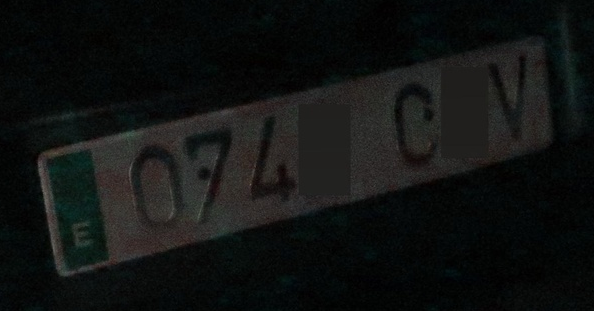

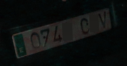

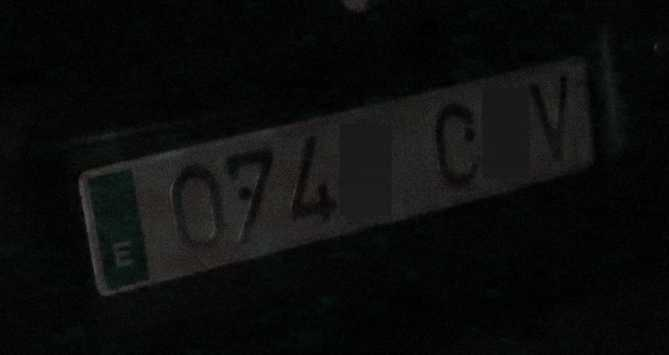

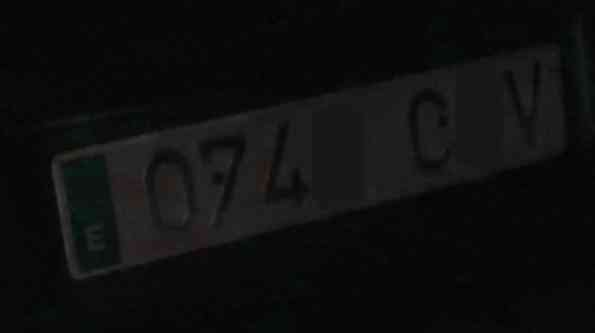

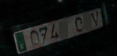

In [8]:
from IPython.display import display

fila = 0
print(train_df["text"][fila])
display(PlateDataset(str(DATA_DIR / "image") + "/", train_df, processor).load_image(fila))
for _ in range(4):
    display(train_dataset.load_image(fila))

## Entrenar el modelo

Como en IAM, partimos de `microsoft/trocr-base-stage1`, el checkpoint preentrenado de TrOCR pensado para ajustarlo a un
dominio nuevo.

In [9]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-stage1 and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Configuramos los tokens especiales, el tamaño del vocabulario y los parámetros de beam search. Respecto a IAM:
`max_length=16` (una placa ocupa como máximo 9 tokens), `no_repeat_ngram_size=0` (una placa puede repetir caracteres,
como `444**PC`) y `length_penalty=1.0` (no hay que favorecer textos largos).

In [10]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 16
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 0
model.config.length_penalty = 1.0
model.config.num_beams = 4

# Las versiones actuales consultan generation_config durante generate().
from transformers import GenerationConfig
model.generation_config = GenerationConfig.from_model_config(model.config)

Hiperparámetros de entrenamiento: batch de 16, hasta 40 épocas, evaluación y guardado al final de cada época, y *early
stopping* si el CER de validación no mejora en 5 épocas seguidas. Al terminar se carga el checkpoint con menor CER.
Los checkpoints se guardan en `outputs/trocr_placas/checkpoints`.

Si falta memoria de GPU, usa `per_device_train_batch_size=8` con `gradient_accumulation_steps=2`: el batch efectivo
sigue siendo 16.

In [11]:
from transformers import EarlyStoppingCallback, Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=40,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available(),
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    report_to="none",
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
)
early_stopping = EarlyStoppingCallback(early_stopping_patience=5)

/opt/conda/envs/trocr/lib/python3.11/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Evaluamos con el Character Error Rate (CER), disponible en Hugging Face Datasets (ver
[aquí](https://huggingface.co/metrics/cer)), y con la tasa de placas leídas sin errores (`exact_match`).

In [12]:
from datasets import load_metric

cer_metric = load_metric("cer", trust_remote_code=True)

/tmp/ipykernel_4615/2449605343.py:3: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  cer_metric = load_metric("cer", trust_remote_code=True)


In [13]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    exact_match = sum(p.strip() == l.strip() for p, l in zip(pred_str, label_str)) / len(label_str)

    return {"cer": cer, "exact_match": exact_match}

¡A entrenar! `default_data_collator` agrupa los ejemplos en lotes. La evaluación tarda algo porque usa beam search.

In [14]:
from transformers import default_data_collator

# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.image_processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
    callbacks=[early_stopping],
)
trainer.train()
trainer.save_model(str(OUTPUT_DIR / "final"))
processor.save_pretrained(str(OUTPUT_DIR / "final"))
print("Mejor checkpoint:", trainer.state.best_model_checkpoint)
print("Epocas entrenadas:", trainer.state.epoch)

/opt/conda/envs/trocr/lib/python3.11/site-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Cer,Exact Match
1,0.321400,0.233384,0.032236,0.882075
2,0.210200,0.285261,0.048355,0.768868
3,0.163200,0.176779,0.030222,0.858491
4,0.147500,0.219931,0.040296,0.787736
5,0.116600,0.175889,0.030222,0.849057
6,0.129100,0.145308,0.036266,0.853774
7,0.135400,0.152550,0.030893,0.820755
8,0.110100,0.188325,0.035594,0.834906


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'early_stopping': True, 'num_beams': 4}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 16, 'early_stopping': True, 'num_beams': 4}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead.

Mejor checkpoint: /home/mambauser/workspace/outputs/trocr_placas/checkpoints/checkpoint-348
Epocas entrenadas: 8.0


## Evaluar

Evaluamos el mejor modelo con la partición `test`, que no se ha usado para entrenar ni para elegir el checkpoint:
primero con los recortes a resolución completa y después con las placas reducidas a 100 píxeles de ancho, que se parece
más a lo que recibe el OCR en el pipeline. El aviso *early stopping required metric_for_best_model* que aparece aquí
es normal: el callback solo actúa durante el entrenamiento.

In [15]:
test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="test")
test_low_res_metrics = trainer.evaluate(eval_dataset=test_low_res_dataset, metric_key_prefix="test_100px")
pd.DataFrame({
    "completa": {k.removeprefix("test_"): v for k, v in test_metrics.items()},
    "100 px": {k.removeprefix("test_100px_"): v for k, v in test_low_res_metrics.items()},
})

early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_cer so early stopping is disabled


,completa,100 px
loss,0.174311,0.174966
cer,0.030523,0.030523
exact_match,0.885947,0.885947
runtime,45.221400,44.229900
samples_per_second,10.858000,11.101000
steps_per_second,0.686000,0.701000
epoch,8.000000,8.000000


## Inferencia

Cargamos el modelo guardado en `outputs/trocr_placas/final` y leemos algunas placas de test.

In [16]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_DIR = str(OUTPUT_DIR / "final")
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(device)
model.eval()

def transcribir(image):
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    pixel_values = processor(image.convert("RGB"), return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)  # usa generation_config guardado (beam search, max_length...)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

for idx in test_df.sample(8, random_state=SEED).index:
    real = test_df["text"][idx]
    prediccion = transcribir(test_dataset.load_image(idx))
    print(f"{test_df['file_name'][idx]:<22} real: {real:<9} leido: {prediccion:<9} {'OK' if prediccion == real else 'X'}")

test/01796_0.jpg       real: 71*9GH*   leido: 71*9GH*   OK
test/00320_0.jpg       real: 98*0*CY   leido: 98*0*CY   OK
test/01692_0.jpg       real: 83*7DG*   leido: 83*7DG*   OK
test/01883_0.jpg       real: 38*6*KS   leido: 38*6*KS   OK
test/01678_0.jpg       real: *012*PK   leido: *013*PK   X
test/01220_0.jpg       real: 61*1JZ*   leido: 61*1JZ*   OK
test/00151_0.jpg       real: 538*F*G   leido: 538*F*G   OK
test/00873_1.jpg       real: 77*0*CN   leido: 77*0*CN   OK


También con una foto de placa sin anonimizar, si existe en `data/IAM/image/internet`:

467*NH


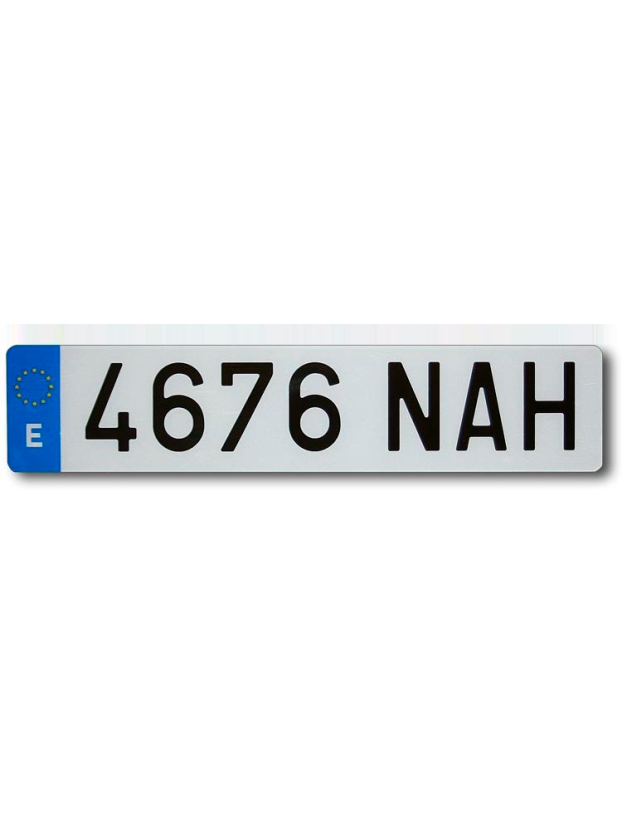

In [17]:
ejemplo = project_dir / "data" / "IAM" / "image" / "internet" / "placa-matricula-acrilica-normal-para-coche.jpg"
if ejemplo.is_file():
    print(transcribir(ejemplo))
    display(Image.open(ejemplo))